<a href="https://colab.research.google.com/github/Despectinator/AIML-Internship-Muhammad-Ali/blob/main/Assignment2_Muhammad_Ali.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2: End-to-End Regression Project
## Insurance Cost Prediction — From Raw Data to a Deployable Model

**Goal:** Build a complete regression pipeline on the Medical Insurance Cost dataset — from raw data, through feature engineering, to a trained, evaluated, and saved model that can make predictions on new inputs.

**Sections:**
1. Data Loading & Exploration
2. Feature Engineering
3. Model Building (Simple, Multiple, Polynomial Regression)
4. Model Evaluation
5. Model Selection & Interpretation
6. Lightweight Model Deployment

## 1. Data Loading & Exploration

In [4]:
from google.colab import files
import os

# Upload insurance.csv from your local machine
print("Please select 'insurance.csv' for upload:")
uploaded = files.upload()

# Detect if the file was renamed during upload
filename = next((name for name in uploaded.keys() if 'insurance' in name and name.endswith('.csv')), None)

if filename:
    # Rename to the standard 'insurance.csv' expected by the following cells
    if filename != 'insurance.csv':
        if os.path.exists('insurance.csv'):
            os.remove('insurance.csv')
        os.rename(filename, 'insurance.csv')
    print("\nSuccessfully uploaded and prepared insurance.csv")
else:
    print("\nWarning: 'insurance.csv' was not found in the uploaded files.")


Please select 'insurance.csv' for upload:


Saving insurance.csv to insurance (2).csv

Successfully uploaded and prepared insurance.csv


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load the prepared insurance.csv
file_path = "insurance.csv"
if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print("Shape:", df.shape)
    display(df.head())
else:
    print(f"Error: {file_path} not found. Please ensure the upload cell above ran successfully.")

Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
print("Column data types:")
print(df.dtypes)
print("\nSummary statistics (numeric columns):")
df.describe()

Column data types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Summary statistics (numeric columns):


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nNumber of duplicate rows:", df.duplicated().sum())

# One duplicate row found - drop it
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after dropping duplicates:", df.shape)

Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Number of duplicate rows: 1
Shape after dropping duplicates: (1337, 7)


**Findings:** The dataset has 1,338 rows and 7 columns (`age`, `sex`, `bmi`, `children`, `smoker`, `region`, `charges`), with no missing values but **1 duplicate row**, which we dropped. Three columns (`sex`, `smoker`, `region`) are categorical (`object` dtype) and will need encoding before modeling.

Skewness of charges: 1.5153909108403483


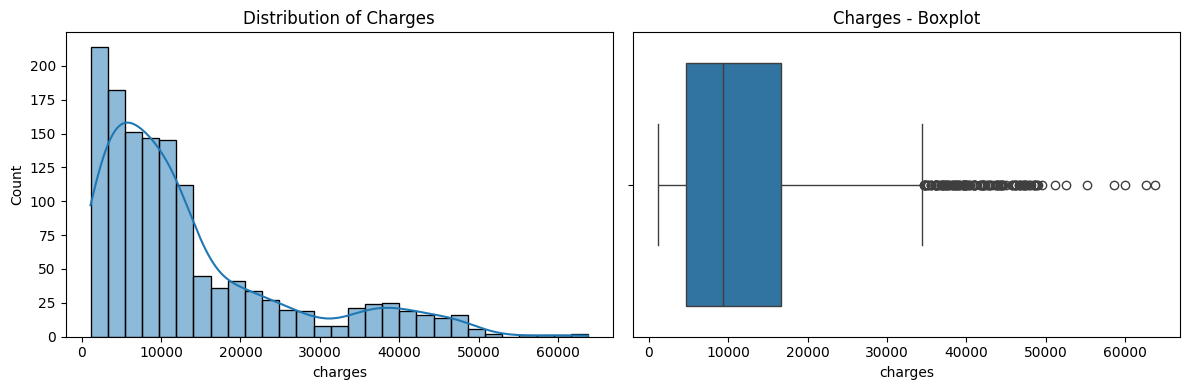

In [8]:
print("Skewness of charges:", df["charges"].skew())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["charges"], kde=True, ax=axes[0])
axes[0].set_title("Distribution of Charges")
sns.boxplot(x=df["charges"], ax=axes[1])
axes[1].set_title("Charges - Boxplot")
plt.tight_layout()
plt.show()

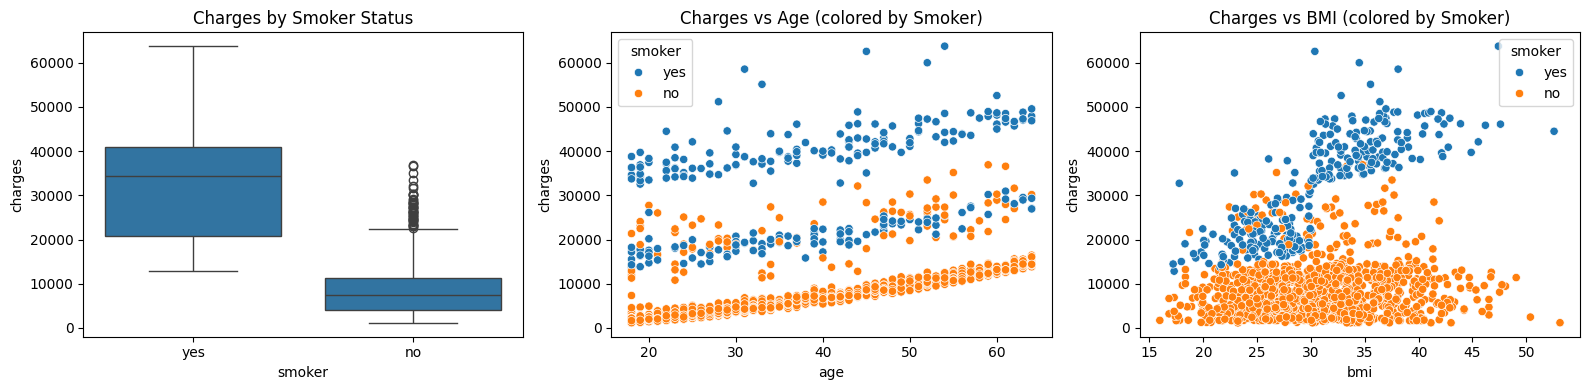

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.boxplot(x="smoker", y="charges", data=df, ax=axes[0])
axes[0].set_title("Charges by Smoker Status")

sns.scatterplot(x="age", y="charges", hue="smoker", data=df, ax=axes[1])
axes[1].set_title("Charges vs Age (colored by Smoker)")

sns.scatterplot(x="bmi", y="charges", hue="smoker", data=df, ax=axes[2])
axes[2].set_title("Charges vs BMI (colored by Smoker)")

plt.tight_layout()
plt.show()

**Exploration notes:**
- `charges` is **heavily right-skewed** (skewness ≈ 1.5) — most people have relatively low medical costs, with a long tail of expensive cases. This suggests a **log transformation** would help linear models fit the data better.
- **Smoker status** is clearly the strongest visual driver of cost: smokers have a much higher and more spread-out charge distribution than non-smokers.
- **Age** shows a positive relationship with charges, and this relationship is steeper for smokers than non-smokers (their costs climb faster with age).
- **BMI** alone shows a weaker relationship with charges for non-smokers, but for smokers, higher BMI appears to push charges even higher — hinting at an interaction effect between `smoker` and other features.

## 2. Feature Engineering

In [10]:
df_fe = df.copy()

# sex: binary nominal category -> label encode (only 2 values, no false ordering risk)
df_fe["sex_encoded"] = df_fe["sex"].map({"male": 0, "female": 1})

# smoker: binary nominal category -> label encode (only 2 values, same reasoning as sex)
df_fe["smoker_encoded"] = df_fe["smoker"].map({"no": 0, "yes": 1})

# region: 4 categories with NO natural order -> one-hot encode to avoid implying a false ranking
df_fe = pd.get_dummies(df_fe, columns=["region"], drop_first=True)

df_fe.head()

,age,sex,bmi,children,smoker,charges,sex_encoded,smoker_encoded,region_northwest,region_southeast,region_southwest
0,19,female,27.900,0,yes,16884.92400,1,1,False,False,True
1,18,male,33.770,1,no,1725.55230,0,0,False,True,False
2,28,male,33.000,3,no,4449.46200,0,0,False,True,False
3,33,male,22.705,0,no,21984.47061,0,0,True,False,False
4,32,male,28.880,0,no,3866.85520,0,0,True,False,False


**Encoding choices:**
- `sex` and `smoker` are both binary (only 2 categories), so **label encoding** (0/1) is safe here — with only two values, there's no risk of implying a false order, and it avoids creating extra columns.
- `region` has 4 unrelated categories (northeast, northwest, southeast, southwest) with no natural ranking, so **one-hot encoding** (`drop_first=True`) is the safer choice to avoid suggesting an order that doesn't exist.

In [11]:
# Derived feature 1: BMI category (standard clinical BMI bands)
df_fe["bmi_category"] = pd.cut(
    df_fe["bmi"],
    bins=[0, 18.5, 25, 30, 100],
    labels=["Underweight", "Normal", "Overweight", "Obese"]
)
print(df_fe["bmi_category"].value_counts())

# Derived feature 2: interaction between smoking and age
# (captures that the cost impact of smoking grows/changes with age, not just additively)
df_fe["smoker_age_interaction"] = df_fe["smoker_encoded"] * df_fe["age"]

df_fe[["bmi", "bmi_category", "age", "smoker", "smoker_age_interaction"]].head()

bmi_category
Obese          704
Overweight     386
Normal         226
Underweight     21
Name: count, dtype: int64


,bmi,bmi_category,age,smoker,smoker_age_interaction
0,27.900,Overweight,19,yes,19
1,33.770,Obese,18,no,0
2,33.000,Obese,28,no,0
3,22.705,Normal,33,no,0
4,28.880,Overweight,32,no,0


**Derived features:**
1. `bmi_category` bins the continuous `bmi` column into standard clinical categories (Underweight/Normal/Overweight/Obese). This makes it easier to interpret and spot non-linear jumps in cost around the Overweight/Obese thresholds.
2. `smoker_age_interaction` (`smoker_encoded × age`) captures the fact that, from the exploration step, **age and smoking interact**: charges for smokers rise faster with age than they do for non-smokers. A plain linear model without this term can't represent that interaction on its own.

Skew before log transform: 1.5153909108403483
Skew after log transform: -0.08955835073325998


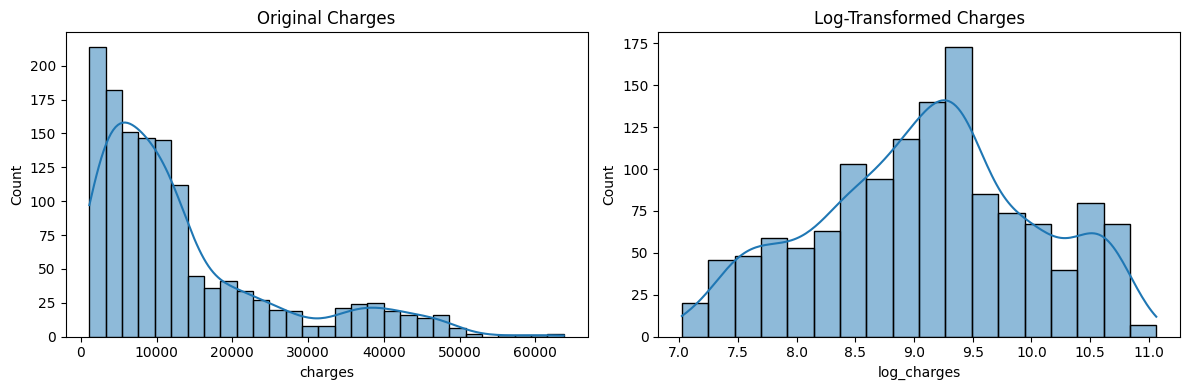

In [12]:
# charges is skewed (skew ~1.5) -> log-transform the target so linear models fit better
df_fe["log_charges"] = np.log1p(df_fe["charges"])

print("Skew before log transform:", df_fe["charges"].skew())
print("Skew after log transform:", df_fe["log_charges"].skew())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_fe["charges"], kde=True, ax=axes[0])
axes[0].set_title("Original Charges")
sns.histplot(df_fe["log_charges"], kde=True, ax=axes[1])
axes[1].set_title("Log-Transformed Charges")
plt.tight_layout()
plt.show()

**Log transformation:** `charges` has a skewness of ~1.5 (heavily right-skewed), which violates the roughly-normal-residuals assumption linear regression works best under, and lets a few very expensive cases dominate the error. Applying `np.log1p()` brings the skewness down close to 0. We'll **train our models to predict `log_charges`**, then convert predictions back to dollars with `np.expm1()` when reporting metrics, so R²/MAE/RMSE stay interpretable in real currency.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

region_cols = [c for c in df_fe.columns if c.startswith("region_")]
feature_cols = ["age", "bmi", "children", "sex_encoded", "smoker_encoded",
                 "smoker_age_interaction"] + region_cols

X = df_fe[feature_cols]
y = df_fe["log_charges"]

# consistent split (same random_state) used for every model below
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# keep the original-dollar charges aligned to the same train/test rows, for reporting metrics
charges_train = df_fe.loc[y_train.index, "charges"]
charges_test = df_fe.loc[y_test.index, "charges"]

print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0])

Train size: 1069  Test size: 268


In [14]:
# Scale numeric features (fit on training data only, then apply to test data)
num_cols = ["age", "bmi", "children", "smoker_age_interaction"]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

X_train_scaled.head()

,age,bmi,children,sex_encoded,smoker_encoded,smoker_age_interaction,region_northwest,region_southeast,region_southwest
1113,-1.157680,-0.996928,-0.907908,0,0,-0.462805,False,False,False
967,-1.300619,-0.792762,0.766904,0,0,-0.462805,False,False,False
598,0.914926,1.154664,0.766904,1,0,-0.462805,True,False,False
170,1.701087,1.806837,-0.907908,0,0,-0.462805,False,True,False
275,0.557580,-0.651417,0.766904,1,0,-0.462805,False,False,False


**Scaling:** We scale the continuous numeric columns (`age`, `bmi`, `children`, `smoker_age_interaction`) with `StandardScaler`, fit only on the training set to avoid leaking test-set information. This matters most for the polynomial model (squared terms can get very large) and makes the linear model's coefficients more directly comparable to each other. The already-binary/one-hot columns (`sex_encoded`, `smoker_encoded`, `region_*`) are left as 0/1 and don't need scaling.

## 3. Model Building

We train three regression approaches on the **same train/test split** so their metrics are directly comparable. A small helper function converts predictions and targets back to the original dollar scale before scoring, since we trained on `log_charges`.

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(name, y_true_log, y_pred_log, results_list):
    """Converts log-scale predictions back to dollars, then computes regression metrics."""
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    print(f"{name:22s}  R2={r2:.4f}   MAE=${mae:,.2f}   MSE={mse:,.0f}   RMSE=${rmse:,.2f}")
    results_list.append({"Model": name, "R2": r2, "MAE": mae, "MSE": mse, "RMSE": rmse})
    return y_pred

results = []

In [16]:
# --- Model 1: Simple Linear Regression ---
# From the exploration step, "smoker" showed the clearest single relationship with charges,
# so we use it as the sole predictor here.
model_simple = LinearRegression()
model_simple.fit(X_train_scaled[["smoker_encoded"]], y_train)

pred_simple_log = model_simple.predict(X_test_scaled[["smoker_encoded"]])
_ = evaluate_model("Simple LR (smoker)", y_test, pred_simple_log, results)

Simple LR (smoker)      R2=0.6357   MAE=$5,979.64   MSE=66,944,615   RMSE=$8,181.97


In [17]:
# --- Model 2: Multiple Linear Regression ---
# Uses every engineered feature: age, bmi, children, sex, smoker, the smoker-age
# interaction, and the one-hot encoded region columns.
model_multi = LinearRegression()
model_multi.fit(X_train_scaled, y_train)

pred_multi_log = model_multi.predict(X_test_scaled)
_ = evaluate_model("Multiple LR (all features)", y_test, pred_multi_log, results)

Multiple LR (all features)  R2=0.7801   MAE=$3,649.55   MSE=40,414,980   RMSE=$6,357.28


In [18]:
# --- Model 3: Polynomial Regression ---
# Applies degree-2 polynomial expansion to the two continuous features that showed
# curved/interacting relationships with charges (age, bmi), then combines them with
# the remaining features for a fair, apples-to-apples comparison.
poly = PolynomialFeatures(degree=2, include_bias=False)

poly_train = poly.fit_transform(X_train_scaled[["age", "bmi"]])
poly_test = poly.transform(X_test_scaled[["age", "bmi"]])
poly_feature_names = poly.get_feature_names_out(["age", "bmi"])

poly_train_df = pd.DataFrame(poly_train, columns=poly_feature_names, index=X_train_scaled.index)
poly_test_df = pd.DataFrame(poly_test, columns=poly_feature_names, index=X_test_scaled.index)

other_cols = [c for c in feature_cols if c not in ["age", "bmi"]]
X_train_poly = pd.concat([poly_train_df, X_train_scaled[other_cols]], axis=1)
X_test_poly = pd.concat([poly_test_df, X_test_scaled[other_cols]], axis=1)

model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)

pred_poly_log = model_poly.predict(X_test_poly)
_ = evaluate_model("Polynomial LR (deg=2)", y_test, pred_poly_log, results)

Polynomial LR (deg=2)   R2=0.7756   MAE=$3,654.25   MSE=41,235,335   RMSE=$6,421.47


## 4. Model Evaluation

In [19]:
results_df = pd.DataFrame(results).set_index("Model")
results_df.round(4)

,R2,MAE,MSE,RMSE
Model,,,,
Simple LR (smoker),0.6357,5979.6406,6.694462e+07,8181.9689
Multiple LR (all features),0.7801,3649.5502,4.041498e+07,6357.2777
Polynomial LR (deg=2),0.7756,3654.2452,4.123534e+07,6421.4745


In [20]:
from sklearn.model_selection import cross_val_score

# 5-fold cross-validation on the best-performing model (Multiple Linear Regression)
cv_scores = cross_val_score(LinearRegression(), X_train_scaled, y_train, cv=5, scoring="r2")

print("R2 for each of the 5 folds:", np.round(cv_scores, 4))
print("Average cross-validated R2:", round(cv_scores.mean(), 4))
print("Standard deviation:", round(cv_scores.std(), 4))

R2 for each of the 5 folds: [0.717  0.8357 0.7822 0.7841 0.8176]
Average cross-validated R2: 0.7873
Standard deviation: 0.0406


**Cross-validation note:** the average 5-fold R² (computed on the log-target, (~0.79–0.80), which suggests the Multiple Linear Regression model's performance is stable and not just a lucky split.

## 5. Model Selection & Interpretation

In [21]:
coef_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": model_multi.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

coef_df

,Feature,Coefficient
4,smoker_encoded,2.786384
0,age,0.568176
5,smoker_age_interaction,-0.537975
2,children,0.128233
8,region_southwest,-0.116343
7,region_southeast,-0.109441
1,bmi,0.069486
3,sex_encoded,0.066768
6,region_northwest,-0.034301


**Model selection:** The **Multiple Linear Regression** model is the best choice here. It has the highest R² and the lowest MAE/MSE/RMSE of the three models — noticeably better than the Simple model (which only knows whether someone smokes) and slightly ahead of the Polynomial model. This makes sense: charges depend on a *combination* of factors (age, BMI, smoking, family size, region), not just one variable, so a model using all of them naturally does better. The Polynomial model added curvature on `age`/`bmi` but didn't outperform the simpler multiple regression, suggesting the relationship between those two features and `log_charges` is close enough to linear that the extra squared terms mostly added complexity without much benefit — we don't pick it despite it being more "sophisticated."

**Coefficient interpretation (Multiple LR, on scaled features, predicting `log_charges`):**
- `smoker_encoded` has by far the **largest positive coefficient** — being a smoker is the single biggest driver of higher insurance charges, matching what the exploration step's boxplot showed clearly.
- `age` has the next-largest positive coefficient — costs consistently rise with age, as expected for medical expenses.
- `smoker_age_interaction` has a **negative** coefficient here, which combined with the strong positive `smoker_encoded` and `age` terms reflects that most of the smoker-driven cost jump happens early, rather than compounding indefinitely with age once the model already accounts for `smoker` and `age` separately — i.e., the interaction term is correcting the combined effect rather than adding an entirely new one.
- `children`, `bmi`, and `sex_encoded` all have small positive coefficients — more children, higher BMI, and being female are associated with modestly higher predicted charges, but these effects are far smaller than smoking or age.
- The `region_*` coefficients are all small and negative relative to the baseline region (northeast), suggesting only minor regional cost differences once the other factors are accounted for.

Overall, this matches our expectations from the exploration step: **smoking status and age are the dominant cost drivers**, with everything else playing a smaller, supporting role.

## 6. Lightweight Model Deployment

We save the trained Multiple Linear Regression model (plus the fitted scaler and feature metadata it needs) with `joblib`, then write a `predict_insurance_cost()` function that loads the saved artifact and returns a prediction for a brand-new person, without ever retraining.

In [22]:
import joblib

# Bundle everything the prediction function needs to reproduce the exact same
# preprocessing used during training.
model_bundle = {
    "model": model_multi,
    "scaler": scaler,
    "feature_cols": feature_cols,
    "num_cols": num_cols,
    "region_cols": region_cols
}

joblib.dump(model_bundle, "insurance_cost_model.joblib")
print("Model saved to insurance_cost_model.joblib")

Model saved to insurance_cost_model.joblib


In [31]:
import joblib

# Load the bundle from the joblib file
loaded_bundle = joblib.load('insurance_cost_model.joblib')

# Display the contents
print("Keys in the bundle:", list(loaded_bundle.keys()))
print("\n--- Model Details ---")
print(loaded_bundle['model'])

print("\n--- Feature Metadata ---")
print(f"All Features: {loaded_bundle['feature_cols']}")
print(f"Numeric Scaled Columns: {loaded_bundle['num_cols']}")

Keys in the bundle: ['model', 'scaler', 'feature_cols', 'num_cols', 'region_cols']

--- Model Details ---
LinearRegression()

--- Feature Metadata ---
All Features: ['age', 'bmi', 'children', 'sex_encoded', 'smoker_encoded', 'smoker_age_interaction', 'region_northwest', 'region_southeast', 'region_southwest']
Numeric Scaled Columns: ['age', 'bmi', 'children', 'smoker_age_interaction']


/usr/local/lib/python3.13/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LinearRegression from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [29]:
def predict_insurance_cost(age, sex, bmi, children, smoker, region):
    """
    Loads the saved model and returns a predicted insurance charge for a new person.

    Parameters:
        age (int/float), sex ('male'/'female'), bmi (float),
        children (int), smoker ('yes'/'no'),
        region ('northeast'/'northwest'/'southeast'/'southwest')

    Returns:
        Predicted charge in dollars (float).
    """
    bundle = joblib.load("insurance_cost_model.joblib")
    model = bundle["model"]
    scaler = bundle["scaler"]
    feature_cols = bundle["feature_cols"]
    num_cols = bundle["num_cols"]
    region_cols = bundle["region_cols"]

    sex_encoded = 0 if sex == "male" else 1
    smoker_encoded = 1 if smoker == "yes" else 0
    smoker_age_interaction = smoker_encoded * age

    row = {
        "age": age, "bmi": bmi, "children": children,
        "sex_encoded": sex_encoded, "smoker_encoded": smoker_encoded,
        "smoker_age_interaction": smoker_age_interaction
    }
    # one-hot region columns, all 0 except the matching region (northeast is the dropped baseline)
    for rc in region_cols:
        row[rc] = 0
    target_col = f"region_{region}"
    if target_col in row:
        row[target_col] = 1

    X_new = pd.DataFrame([row])[feature_cols]
    X_new_scaled = X_new.copy()
    X_new_scaled[num_cols] = scaler.transform(X_new[num_cols])

    log_pred = model.predict(X_new_scaled)[0]
    return float(np.expm1(log_pred))

# 1. Call the function and store the 'returned' value in a variable
prediction = predict_insurance_cost(age=30, sex='male', bmi=25.0, children=0, smoker='no', region='northeast')

# 2. Now print the variable to see what was returned
print(f"The function returned: ${prediction:,.2f}")

The function returned: $3,879.26


In [25]:
# Test with 2 example people
example_1 = predict_insurance_cost(age=19, sex="female", bmi=27.9, children=0, smoker="yes", region="southwest")
example_2 = predict_insurance_cost(age=45, sex="male", bmi=30.0, children=2, smoker="no", region="northeast")

print(f"Example 1 (19yo female, BMI 27.9, smoker):     Predicted charge = ${example_1:,.2f}")
print(f"Example 2 (45yo male, BMI 30.0, non-smoker):    Predicted charge = ${example_2:,.2f}")

Example 1 (19yo female, BMI 27.9, smoker):     Predicted charge = $21,310.32
Example 2 (45yo male, BMI 30.0, non-smoker):    Predicted charge = $9,366.18


### Summary

We built a complete regression pipeline on the medical insurance dataset: explored and cleaned the data, engineered features (encoding, a BMI category, a smoker×age interaction, and a log-transformed target), trained and fairly compared three regression approaches, and selected **Multiple Linear Regression** as the best model based on R²/MAE/RMSE and 5-fold cross-validation. Smoking status and age were confirmed as the dominant cost drivers. Finally, the model was saved with `joblib` and wrapped in a `predict_insurance_cost()` function that can generate predictions for new people without retraining — a first, lightweight step toward deployment.